Connected to Python 3.11.9

In [ ]:
# Autoregressive Models

In [ ]:
# import libraries
import warnings
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from pymongo import MongoClient
from sklearn.metrics import mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg

In [ ]:
# connect to MongoDB
client = MongoClient("mongodb://127.0.0.1:27017")
# Assign database
db = client["air-quality"]
# Assign collection
nairobi = db["nairobi"]

In [ ]:
# Wrangle Function from MongoDB_1
def wrangle(collection):
    results = collection.find(
        {"metadata.site": 29, "metadata.measurement": "P2"},
        projection={"P2": 1, "timestamp": 1, "_id": 0}
    )
    df = pd.DataFrame(results)
    # Convert timestamp column to datetime
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    # Set as index
    df = df.set_index("timestamp")
    # If timezone-naive → localize
    if df.index.tz is None:
        df.index = df.index.tz_localize("UTC")
    
    # localised timezone
    df.index = df.index.tz_convert("UTC").tz_convert("Africa/Nairobi")
    
    #Remove Outliers
    df = df[df["P2"] < 500]
    
    # Resample to 1 hour window, fill missing values
    df = df["P2"].resample("h").mean().ffill().to_frame() # updated syntax

    return df

In [ ]:
y = wrangle(nairobi)
print(y.shape)
y.head()

(2928, 1)


,P2
timestamp,
2018-09-01 03:00:00+03:00,17.541667
2018-09-01 04:00:00+03:00,15.800000
2018-09-01 05:00:00+03:00,11.420000
2018-09-01 06:00:00+03:00,11.614167
2018-09-01 07:00:00+03:00,17.665000


In [ ]:
# Wrangle Function from MongoDB_1
def wrangle(collection):
    results = collection.find(
        {"metadata.site": 29, "metadata.measurement": "P2"},
        projection={"P2": 1, "timestamp": 1, "_id": 0}
    )
    df = pd.DataFrame(results)
    # Convert timestamp column to datetime
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    # Set as index
    df = df.set_index("timestamp")
    # If timezone-naive → localize
    if df.index.tz is None:
        df.index = df.index.tz_localize("UTC")
    
    # localised timezone
    df.index = df.index.tz_convert("UTC").tz_convert("Africa/Nairobi")
    
    #Remove Outliers
    df = df[df["P2"] < 500]
    
    # Resample to 1 hour window, fill missing values
    df = df["P2"].resample("h").mean().ffill() # updated syntax

    return df
#...................................................
y = wrangle(nairobi)
print(y.shape)
y.head()

(2928,)


timestamp
2018-09-01 03:00:00+03:00    17.541667
2018-09-01 04:00:00+03:00    15.800000
2018-09-01 05:00:00+03:00    11.420000
2018-09-01 06:00:00+03:00    11.614167
2018-09-01 07:00:00+03:00    17.665000
Freq: h, Name: P2, dtype: float64

In [ ]:
y.corr(y)

np.float64(1.0)

In [ ]:
y.corr(y.shift(1))

np.float64(0.6506785333937846)

In [ ]:
y.corr(y.shift(2))

np.float64(0.44267376546649534)

In [ ]:
# as the lag increases, the correlation decreases
# or predictability decreases

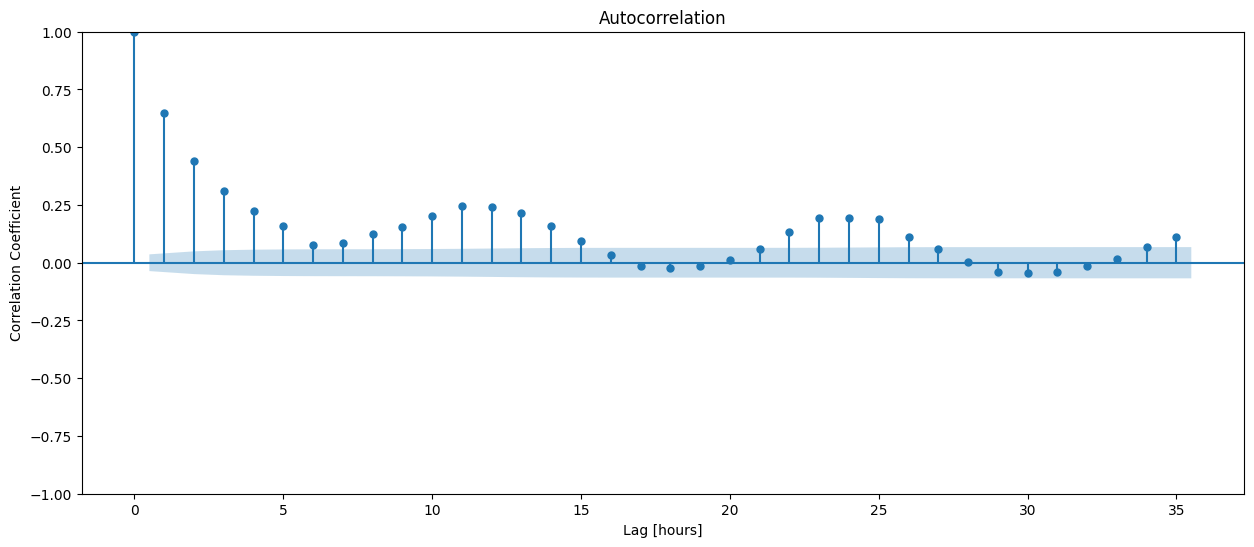

In [ ]:
#  ACF plot for the data in y
fig, ax = plt.subplots(figsize=(15, 6))
plot_acf(y, ax=ax)
plt.xlabel("Lag [hours]")
plt.ylabel("Correlation Coefficient");

In [ ]:
y.corr(y.shift(1))

np.float64(0.6506785333937846)

In [ ]:
y.shift(1).corr(y.shift(1))

np.float64(1.0)

In [ ]:
y.shift(1).corr(y.shift(2))

np.float64(0.650681090074551)

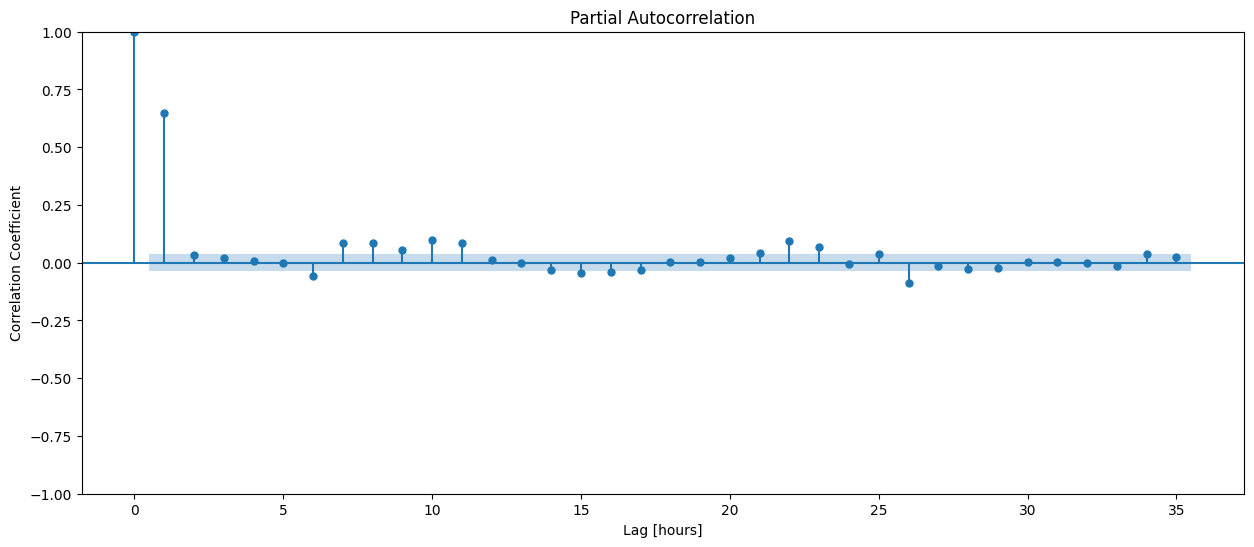

In [ ]:
# PACF plot for the data in y
fig, ax = plt.subplots(figsize=(15, 6))
plot_pacf(y, ax=ax)
plt.xlabel("Lag [hours]")
plt.ylabel("Correlation Coefficient");

In [ ]:
len (y) * 0.95

2781.6

In [ ]:
int(len (y) * 0.95)

2781

In [ ]:
cutoff_test = int(len (y) * 0.95)

y_train = y[:cutoff_test]
y_test = y[cutoff_test:]

In [ ]:
# check lengths
len(y_train) + len(y_test) == len(y)

True

In [ ]:
# Basline
y_train_mean = y_train.mean()
y_pred_baseline = [y_train_mean] * len(y_train)
mae_baseline = mean_absolute_error(y_train, y_pred_baseline)

print("Mean P2 Reading:", round(y_train_mean, 2))
print("Baseline MAE:", round(mae_baseline, 2))

Mean P2 Reading: 9.22
Baseline MAE: 3.71


In [ ]:
model = AutoReg(y_train, lags=26).fit()

In [ ]:
model.predict()

timestamp
2018-09-01 03:00:00+03:00         NaN
2018-09-01 04:00:00+03:00         NaN
2018-09-01 05:00:00+03:00         NaN
2018-09-01 06:00:00+03:00         NaN
2018-09-01 07:00:00+03:00         NaN
                               ...   
2018-12-25 19:00:00+03:00    8.452835
2018-12-25 20:00:00+03:00    8.706514
2018-12-25 21:00:00+03:00    7.862413
2018-12-25 22:00:00+03:00    7.766388
2018-12-25 23:00:00+03:00    6.484643
Freq: h, Length: 2781, dtype: float64

In [ ]:
model.predict().isnull().sum()

np.int64(26)

In [ ]:
y_pred = model.predict().dropna()
training_mae = mean_absolute_error(y_train.iloc[26:], y_pred)
print("Training MAE:", training_mae)

Training MAE: 2.2809871656467036


In [ ]:
# Residual Analysis
y_train_resid = y_train- y_pred # or y_train_resid = model.resid
y_train_resid.tail()

timestamp
2018-12-25 19:00:00+03:00   -0.392002
2018-12-25 20:00:00+03:00   -1.573180
2018-12-25 21:00:00+03:00   -0.735747
2018-12-25 22:00:00+03:00   -2.022221
2018-12-25 23:00:00+03:00   -0.061916
Freq: h, dtype: float64

<Axes: xlabel='timestamp', ylabel='residual Value'>

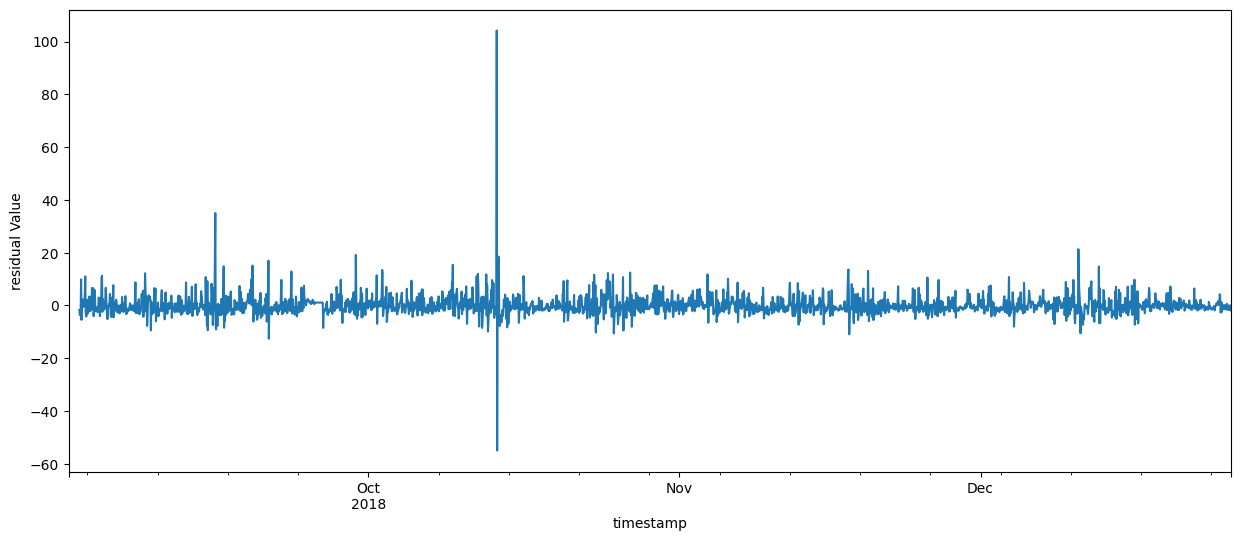

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6))
y_train_resid.plot(ylabel= "residual Value", ax=ax)

<Axes: >

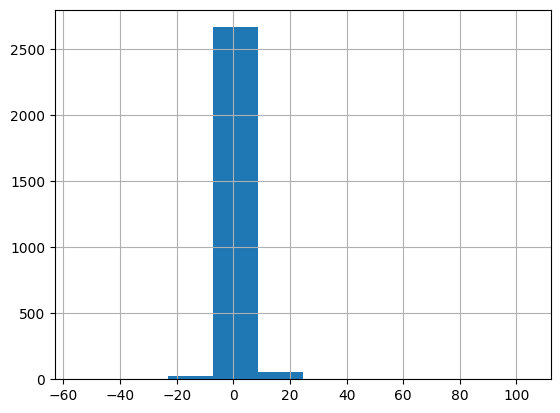

In [ ]:
y_train_resid.hist()

In [ ]:
y_train_resid.describe()

count    2.755000e+03
mean     1.898735e-14
std      3.955016e+00
min     -5.505086e+01
25%     -1.763319e+00
50%     -5.199961e-01
75%      1.123584e+00
max      1.041694e+02
dtype: float64

In [ ]:
type(y_train_resid.index)

pandas.core.indexes.datetimes.DatetimeIndex

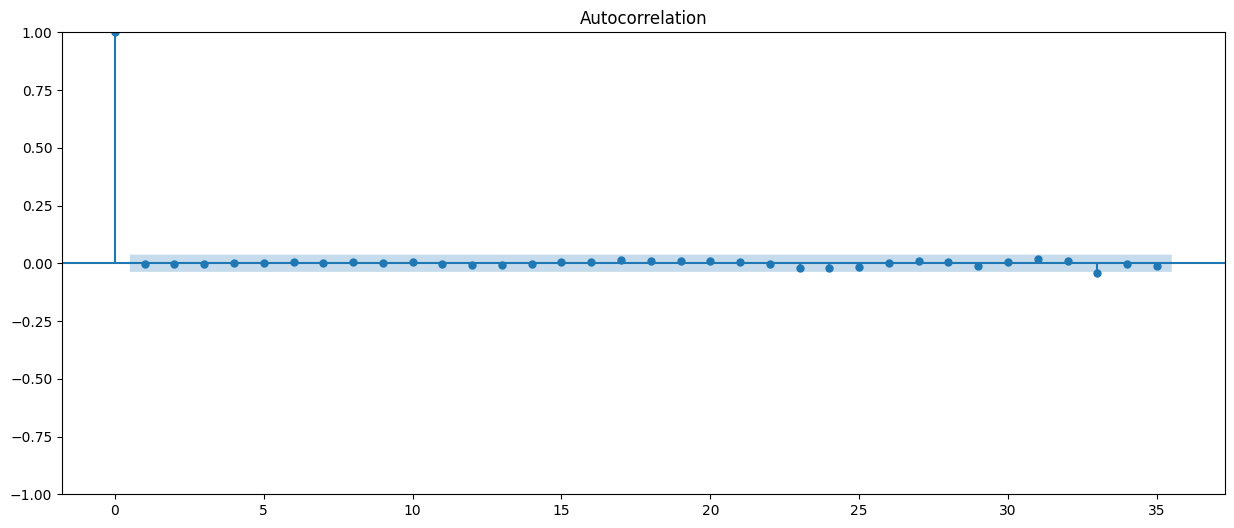

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6))
plot_acf(y_train_resid.iloc[26:], ax=ax);

In [ ]:
y_test.head()

timestamp
2018-12-26 00:00:00+03:00    5.679091
2018-12-26 01:00:00+03:00    5.362500
2018-12-26 02:00:00+03:00    4.786667
2018-12-26 03:00:00+03:00    4.956667
2018-12-26 04:00:00+03:00    5.055833
Freq: h, Name: P2, dtype: float64

In [ ]:
y_test.tail()

timestamp
2018-12-31 22:00:00+03:00     7.060833
2018-12-31 23:00:00+03:00     7.854167
2019-01-01 00:00:00+03:00     9.755833
2019-01-01 01:00:00+03:00    12.665000
2019-01-01 02:00:00+03:00    18.803333
Freq: h, Name: P2, dtype: float64

In [ ]:
y_pred_test = model.predict(y_test.index.min(), y_test.index.max())
test_mae = mean_absolute_error(y_test, y_pred_test)
print("Test MAE:", test_mae)

Test MAE: 3.0136439495039085


In [ ]:
df_pred_test = pd.DataFrame(
    {"y_test": y_test, "y_pred": y_pred_test}, index=y_test.index
)

In [ ]:
df_pred_test.head()

,y_test,y_pred
timestamp,,
2018-12-26 00:00:00+03:00,5.679091,6.717606
2018-12-26 01:00:00+03:00,5.362500,7.259274
2018-12-26 02:00:00+03:00,4.786667,7.311588
2018-12-26 03:00:00+03:00,4.956667,7.551141
2018-12-26 04:00:00+03:00,5.055833,7.744001


In [ ]:
print(df_pred_test.shape)

(147, 2)


In [ ]:
fig = px.line(df_pred_test, labels={"value": "P2"})
fig.show()

In [ ]:
# Walk-Forward Validation
y_pred_wfv = pd.Series()
history = y_train.copy()
for i in range(len(y_test)):
    pass

In [ ]:
history.tail(1)

timestamp
2018-12-25 23:00:00+03:00    6.422727
Freq: h, Name: P2, dtype: float64

In [ ]:
y_test.head(1)

timestamp
2018-12-26 00:00:00+03:00    5.679091
Freq: h, Name: P2, dtype: float64

In [ ]:
model.forecast()

2018-12-26 00:00:00+03:00    6.717606
Freq: h, dtype: float64

In [ ]:
# New code
y_pred_wfv = pd.Series(dtype=float)   # specify dtype
history = y_train.copy()

for i in range(len(y_test)):
    model = AutoReg(history, lags=26).fit()
    next_pred = model.forecast()

    # concatenate instead of append
    y_pred_wfv = pd.concat([y_pred_wfv, next_pred])

    # update history safely
    history = pd.concat([history, y_test[next_pred.index]])

In [ ]:
# test MAE for WFV
test_mae = mean_absolute_error(y_test, y_pred_wfv)
print("Test MAE (WFV):", round(test_mae, 2))

Test MAE (WFV): 1.4


In [ ]:
print(model.params)

const     2.011432
P2.L1     0.587118
P2.L2     0.019796
P2.L3     0.023615
P2.L4     0.027187
P2.L5     0.044014
P2.L6    -0.102128
P2.L7     0.029583
P2.L8     0.049867
P2.L9    -0.016897
P2.L10    0.032438
P2.L11    0.064360
P2.L12    0.005987
P2.L13    0.018375
P2.L14   -0.007636
P2.L15   -0.016075
P2.L16   -0.015953
P2.L17   -0.035444
P2.L18    0.000756
P2.L19   -0.003907
P2.L20   -0.020655
P2.L21   -0.012578
P2.L22    0.052499
P2.L23    0.074229
P2.L24   -0.023806
P2.L25    0.090577
P2.L26   -0.088323
dtype: float64


In [ ]:
print(model.summary())

                            AutoReg Model Results                             
Dep. Variable:                     P2   No. Observations:                 2927
Model:                    AutoReg(26)   Log Likelihood               -8043.341
Method:               Conditional MLE   S.D. of innovations              3.872
Date:                Wed, 03 Dec 2025   AIC                          16142.681
Time:                        16:15:32   BIC                          16309.920
Sample:                    09-02-2018   HQIC                         16202.940
                         - 01-01-2019                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0114      0.267      7.526      0.000       1.488       2.535
P2.L1          0.5871      0.018     31.741      0.000       0.551       0.623
P2.L2          0.0198      0.021      0.925      0.3

In [ ]:
df_pred_test = pd.DataFrame(
    {"y_test": y_test, "y_pred_wfv": y_pred_wfv},
)
fig = px.line(df_pred_test, labels={"value": "P2"})
fig.show()